<a href="https://colab.research.google.com/github/overgroove/samsung_lecture/blob/main/samsung_feature_eng_project_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **삼성전자 feature engineering 프로젝트**
# **기후데이터를 바탕으로 한 건물별 전력사용량 데이터 전처리**

- 한국에너지관리공단 제공 전력사용량 예측 데이터.
  - 2022년 6월 부터 2020년 8월에 걸쳐 수집 된 데이터.  
  - 100개의 건물에서 1시간 단위로 수집한 기후 데이터 및 전력사용량 누적 데이터

- feature engineering 목적
  - 해당 데이터셋의 목적은 전력사용량 예측을 위한 데이터셋을 정제 함에 있다.  
  - 양일 간 학습한 여러가지 특성공학 기법을 실제 데이터에 적용

- 진행방식
  - 아래 굵은 글씨로 작성 되어있는 테스트를 수행하며 테스크 아래 수행 결과값과 비교하며 프로젝트를 진행합니다.    
  - 각 테스트별 세부 테스크의 경우 주석처리한 텍스트를 참고해야 합니다.  
  -  코드 실행 결과값이 없을 경우 # 결과값 없음, 코드 실행 결과가 결과값이랑 다를 수 있는 경우 # 결과값 다를 수 있음으로 가늠합니다.  

### **라이브러리 import 및 한글폰트 설정**

In [ ]:
# 나눔폰트 인스톨
# 아래 코드 그대로 실행 시켜주시면 됩니다.
!apt-get update -qq
!apt-get install -qq fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib
# 해당 코드를 한번 실행 시키신 이후 코랩 상단 메뉴 중 (런타임) --> (세션 다시 시작)을 눌러주세요
# 다시 시작 된 세션에서는 이 코드는 실행 시키지 않으셔도 됩니다. 아래 항목으로 넘어가 주세요.

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no

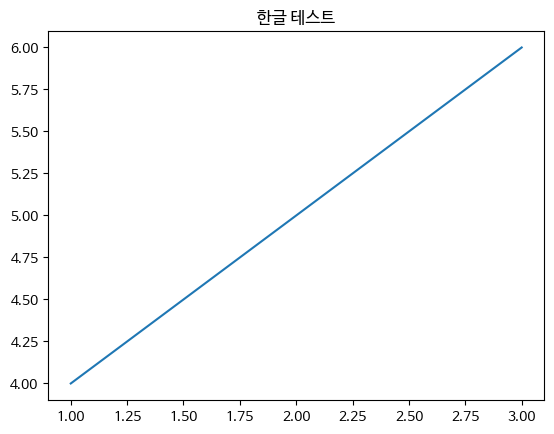

In [ ]:
# 추가적으로 필요한 라이브러리 및 옵션값은 코드를 제공해 드립니다.
# 위 코드 실행 후 세션 재시작 이후에 해당 import 코드를 실행시키면 아래와 같이 시각화 텍스트에 한글이 적용됩니다.
# 만약 한글 적용이 되지 않는다면 프로젝트 수행 전 강사/코치진에게 문의주세요.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings(action='ignore') # 오류메세지 출력 X

plt.rcParams['font.family'] = 'NanumBarunGothic' # 그래프에 표시되는 한글 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 표기 오류 수정
pd.options.display.max_rows=200 # 최대표시 샘플 갯수 설정
pd.options.display.max_columns=200 # 최대표시 변수 갯수 설정
pd.options.display.max_info_columns=200 # info 최대표시 변수 갯수 설정

# Test Plot
plt.title("한글 테스트")
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

### **데이터 로딩 및 확인**
프로젝트 주피터노트북파일과 함께 전달 된 energy_dataset.csv파일을 코랩 환경에 업로드 후 진행합니다.

**1. energy_dataset.csv 파일을 불러들여 df라는 변수 이름을 갖는 데이터프레임으로 할당하고 첫 5개 샘플값 확인**

In [ ]:
# CODE HERE


In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/overgroove/ML_lecture_image_data/refs/heads/main/data/energy_dataset.csv")
df.head()

,건물번호,일시,기온,강수량,풍속,습도,일조,일사,건물유형,전력소비량
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,건물기타,1085.28
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,건물기타,1047.36
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,건물기타,974.88
3,1,20220601 03,16.7,NaN,1.4,48.0,NaN,NaN,건물기타,953.76
4,1,20220601 04,18.4,NaN,2.8,43.0,NaN,NaN,건물기타,986.40


**2. 데이터프레임의 기본 정보 확인을 위해 info() 메소드 호출**

In [ ]:
# CODE HERE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   건물번호    204000 non-null  int64  
 1   일시      204000 non-null  object 
 2   기온      204000 non-null  float64
 3   강수량     43931 non-null   float64
 4   풍속      204000 non-null  float64
 5   습도      204000 non-null  float64
 6   일조      128818 non-null  float64
 7   일사      116087 non-null  float64
 8   건물유형    204000 non-null  object 
 9   전력소비량   204000 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 15.6+ MB


### **결측데이터 확인 및 처리**

**3. 위 결과값을 확인 한 결과 특정 변수에 결측데이터가 있음을 확인하였습니다. 처리 방법에 대한 인사이트를 얻기 위해 아래와 같이 결측데이터의 변수명, 데이터 타입, 결측 데이터 비율을 출력합니다.**

In [ ]:
# CODE HERE


In [ ]:
# 출력형식(소수점 자리수 및 특수기호)는 관계없이 출력되어 있는 내용의 수치까지만 같으면 괜챦습니다.
for col_nm in df.columns:
    print(col_nm, df[col_nm].dtype, f'결측데이터 비율 "{df[col_nm].isna().sum() / len(df) * 100}%')

건물번호 int64 결측데이터 비율 "0.0%
일시 object 결측데이터 비율 "0.0%
기온 float64 결측데이터 비율 "0.0%
강수량 float64 결측데이터 비율 "78.46519607843138%
풍속 float64 결측데이터 비율 "0.0%
습도 float64 결측데이터 비율 "0.0%
일조 float64 결측데이터 비율 "36.85392156862745%
일사 float64 결측데이터 비율 "43.094607843137254%
건물유형 object 결측데이터 비율 "0.0%
전력소비량 float64 결측데이터 비율 "0.0%


풍속, 습도 변수는 실수데이터 이며 결측데이터 갯수가 작아 대표값(평균 혹은 중앙값) 등을 통해 결측데이터를 채워넣는 작업을 하도록 하겠습니다. 대표값 확인을 위해 분포 시각화를 진행합니다.  
**4. 아래 제공 된 코드를 참고하여 풍속, 습보 변수의 히스토그램을 (1, 2) figure에 시각화합니다. ?? 부분을 수정하셔야 합니다.**  

In [ ]:
# CODE HERE
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

for i, col_name in enumerate([??]):
    sns.histplot(data=df, x=col_name, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribution of {col_name}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show();

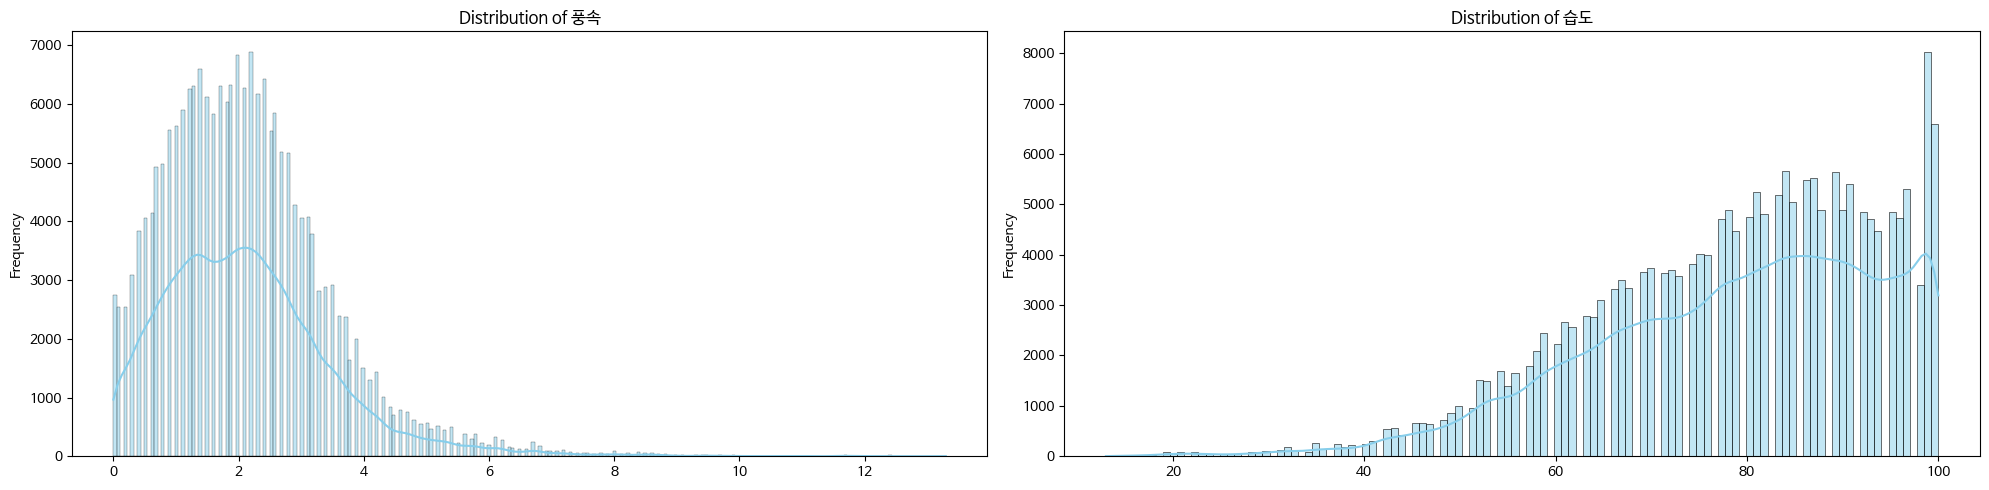

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

for i, col_name in enumerate(['풍속', '습도']):
    sns.histplot(data=df, x=col_name, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribution of {col_name}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show();

**5. 위 히스토그램을 통해 판단한 대표값을 사용하여 풍속, 습도 변수의 결측데이터를 대체합니다.  
판다스 메소드 및 sklearn 메소드 어떤 방법이든 관계없고 본인이 판단하는 값을 기준으로 결측데이터를 처리 하시면 됩니다. 코드 실행 후 작업 결과 확인을 위하여 info 메소드를 호출하여 결측 정보를 확인합니다.**


In [ ]:
# CODE HERE


In [ ]:
df['풍속'] = df['풍속'].fillna(2)
df['습도'] = df['습도'].fillna(100)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   건물번호    204000 non-null  int64  
 1   일시      204000 non-null  object 
 2   기온      204000 non-null  float64
 3   강수량     43931 non-null   float64
 4   풍속      204000 non-null  float64
 5   습도      204000 non-null  float64
 6   일조      128818 non-null  float64
 7   일사      116087 non-null  float64
 8   건물유형    204000 non-null  object 
 9   전력소비량   204000 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 15.6+ MB


풍속, 습도 변수의 결측데이터는 잘 처리 되었습니다. 다만 강수량, 일조, 일사 변수는 결측데이터 비율이 높아 해당 데이터의 처리 방법의 인사이트를 얻기 위해 데이터 확인이 필요합니다.

**6. 데이터프레임의 head()를 활용하여 50개 샘플데이터를 확인합니다.**

In [ ]:
# CODE HERE


In [ ]:
df.head(50)

,건물번호,일시,기온,강수량,풍속,습도,일조,일사,건물유형,전력소비량
0,1,20220601 00,18.6,NaN,0.9,42.0,NaN,NaN,건물기타,1085.28
1,1,20220601 01,18.0,NaN,1.1,45.0,NaN,NaN,건물기타,1047.36
2,1,20220601 02,17.7,NaN,1.5,45.0,NaN,NaN,건물기타,974.88
3,1,20220601 03,16.7,NaN,1.4,48.0,NaN,NaN,건물기타,953.76
4,1,20220601 04,18.4,NaN,2.8,43.0,NaN,NaN,건물기타,986.40
5,1,20220601 05,17.2,NaN,2.1,46.0,NaN,NaN,건물기타,1087.20
6,1,20220601 06,16.3,NaN,1.0,50.0,0.0,0.05,건물기타,1314.72
7,1,20220601 07,17.4,NaN,1.3,50.0,1.0,0.55,건물기타,1684.80
8,1,20220601 08,20.6,NaN,1.8,44.0,1.0,1.29,건물기타,1976.16
9,1,20220601 09,23.2,NaN,1.7,41.0,1.0,2.01,건물기타,2289.12


**7. 위에서 확인 한 데이터를 바탕으로 일조/일사 변수의 결측데이터 패턴을 확인합니다.**  
**어떤 이유에서 결측데이터가 생성되었는지, 이를 바탕으로 결측데이터를 처리해야 한다면 어떤 값이 좋을지 기술합니다.**

In [ ]:
# 서술형 답변이 필요합니다. 아래에 주석 형태로 답변을 남겨주세요.


**8. 위 항목에서 판단한 내용을 바탕으로 강수량, 일조, 일사 변수의 결측치데이터를 채워넣은 후 결측정보를 확인합니다.**

In [ ]:
# CODE HERE


In [ ]:
for col_nm in ['강수량', '일조', '일사']:
    df[col_nm].fillna(0, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   건물번호    204000 non-null  int64  
 1   일시      204000 non-null  object 
 2   기온      204000 non-null  float64
 3   강수량     204000 non-null  float64
 4   풍속      204000 non-null  float64
 5   습도      204000 non-null  float64
 6   일조      204000 non-null  float64
 7   일사      204000 non-null  float64
 8   건물유형    204000 non-null  object 
 9   전력소비량   204000 non-null  float64
dtypes: float64(7), int64(1), object(2)
memory usage: 15.6+ MB


### **날짜형식 데이터 파생변수 생성**

df의 일시 변수는 데이터가 수집 된 날짜 및 시간에 관한 데이터입니다.  
**9. 일시 변수값을 호출하여 데이터 형태 / 타입 / 구성요소를 확인합니다.**

In [ ]:
# CODE HERE


In [ ]:
df['일시']

,일시
0,20220601 00
1,20220601 01
2,20220601 02
3,20220601 03
4,20220601 04
...,...
203995,20220824 19
203996,20220824 20
203997,20220824 21
203998,20220824 22


일시 변수 확인 결과 년/월/일/시간 순으로 누적 된 데이터임을 확인 했습니다.  
문자열 인덱싱을 통해 각 월/일/시간 속성값을 추출하여 변수로 생성하겠습니다.  
**아래 코드는 문자열 중 월/일/시간 항목을 인덱싱하여 리턴값으로 전달하는 함수를 제작하고 날짜형 데이터를 변수형태로 변환하는 코드입니다. 전달드리는 코드 그대로 실행 시켜주세요**

In [ ]:
# 아래 코드 실행
def make_datetime(x):
    return int(x[4:6]), int(x[6:8]), int(x[9:11])

df[['month', 'date', 'hour']] = list(df['일시'].apply(make_datetime))
df.head()

,건물번호,일시,기온,강수량,풍속,습도,일조,일사,건물유형,전력소비량,month,date,hour
0,1,20220601 00,18.6,0.0,0.9,42.0,0.0,0.0,건물기타,1085.28,6,1,0
1,1,20220601 01,18.0,0.0,1.1,45.0,0.0,0.0,건물기타,1047.36,6,1,1
2,1,20220601 02,17.7,0.0,1.5,45.0,0.0,0.0,건물기타,974.88,6,1,2
3,1,20220601 03,16.7,0.0,1.4,48.0,0.0,0.0,건물기타,953.76,6,1,3
4,1,20220601 04,18.4,0.0,2.8,43.0,0.0,0.0,건물기타,986.40,6,1,4


날짜/시간 데이터인 일시 변수를 분해하여 파생변수를 생성 했습니다.  
**10. 기존 일시 변수는 분석에 중복되는 데이터이며 문자열 데이터이기에 삭제합니다. 삭제 후 head() 호출하여 작업결과를 확인합니다.**

In [ ]:
# CODE HERE


In [ ]:
del df['일시']
df.head()

,건물번호,기온,강수량,풍속,습도,일조,일사,건물유형,전력소비량,month,date,hour
0,1,18.6,0.0,0.9,42.0,0.0,0.0,건물기타,1085.28,6,1,0
1,1,18.0,0.0,1.1,45.0,0.0,0.0,건물기타,1047.36,6,1,1
2,1,17.7,0.0,1.5,45.0,0.0,0.0,건물기타,974.88,6,1,2
3,1,16.7,0.0,1.4,48.0,0.0,0.0,건물기타,953.76,6,1,3
4,1,18.4,0.0,2.8,43.0,0.0,0.0,건물기타,986.40,6,1,4


### **카테고리컬 변수 확인**

현재 데이터는 100개의 건물로 부터 수집 된 데이터를 담고 있고 해당 건물의 유형이 건물유형 변수에 저장 되어 있습니다.  
**11. 범주형 변수 처리 방법을 확인 하기 위해 건물번호/ 건물유형 변수의 고윳값을 출력합니다.**

In [ ]:
# CODE HERE


In [ ]:
print(df['건물번호'].unique())
print(df['건물유형'].unique())

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
['건물기타' '공공' '대학교' '데이터센터' '백화점및아울렛' '병원' '상용' '아파트' '연구소' '지식산업센터' '할인마트'
 '호텔및리조트']


### **one hot encoding**
위에서 확인한 고윳값 갯수(카디널리티)에 따르면 건물유형은 one hot encoding을 통해 카테고리컬 데이터의 특성을 반영 시킬 수 있을 것 같습니다.

**12. 건물유형 변수에 onehotencoding을 적용합니다.  
데이터 변환 및 기존 df에 concat으로 병합 후 건물유형 변수를 삭제합니다.  
작업이후 head() 호출하여 작업결과를 확인합니다.**

In [ ]:
# CODE HERE


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
ohe_df = pd.DataFrame(ohe.fit_transform(df[['건물유형']]).toarray(), columns=ohe.get_feature_names_out())
df = pd.concat([df, ohe_df], axis=1)
del df['건물유형']
df.head()

,건물번호,기온,강수량,풍속,습도,일조,일사,전력소비량,month,date,hour,건물유형_건물기타,건물유형_공공,건물유형_대학교,건물유형_데이터센터,건물유형_백화점및아울렛,건물유형_병원,건물유형_상용,건물유형_아파트,건물유형_연구소,건물유형_지식산업센터,건물유형_할인마트,건물유형_호텔및리조트
0,1,18.6,0.0,0.9,42.0,0.0,0.0,1085.28,6,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,18.0,0.0,1.1,45.0,0.0,0.0,1047.36,6,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,17.7,0.0,1.5,45.0,0.0,0.0,974.88,6,1,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,16.7,0.0,1.4,48.0,0.0,0.0,953.76,6,1,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,18.4,0.0,2.8,43.0,0.0,0.0,986.40,6,1,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### **Target encoding**
건물 유형과 달리 건물 번호는 100개의 카디널리티를 갖고 있기에 one hot encoding 변환 시 너무 많은 0 데이터를 갖는 sparse한 데이터가 생성 됩니다.  
이를 방지하면서 각 변수의 구분 통해 예측 결과값에 도움을 줄 수 있도록 target encoding을 수행합니다.

**13. 건물별_전력소비량 파생변수를 생성합니다. 건물번호 단위로 묶인 샘플데이터의 전력소비량 평균값을 매칭시켜 target encoding을 적용한 값을 저장합니다. 작업 이후 head()를 확인하여 작업결과를 확인합니다.**

In [ ]:
target_en = df.groupby('건물번호')['전력소비량'].transform('mean')
df['건물별_전력소비량'] = target_en
df.head()

,건물번호,기온,강수량,풍속,습도,일조,일사,전력소비량,month,date,hour,건물유형_건물기타,건물유형_공공,건물유형_대학교,건물유형_데이터센터,건물유형_백화점및아울렛,건물유형_병원,건물유형_상용,건물유형_아파트,건물유형_연구소,건물유형_지식산업센터,건물유형_할인마트,건물유형_호텔및리조트,건물별_전력소비량
0,1,18.6,0.0,0.9,42.0,0.0,0.0,1085.28,6,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
1,1,18.0,0.0,1.1,45.0,0.0,0.0,1047.36,6,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
2,1,17.7,0.0,1.5,45.0,0.0,0.0,974.88,6,1,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
3,1,16.7,0.0,1.4,48.0,0.0,0.0,953.76,6,1,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
4,1,18.4,0.0,2.8,43.0,0.0,0.0,986.40,6,1,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412


**14. target encoding을 위해 사용한 건물번호 변수는 삭제 후 head()를 확인합니다.**

In [ ]:
del df['건물번호']
df.head()

,기온,강수량,풍속,습도,일조,일사,전력소비량,month,date,hour,건물유형_건물기타,건물유형_공공,건물유형_대학교,건물유형_데이터센터,건물유형_백화점및아울렛,건물유형_병원,건물유형_상용,건물유형_아파트,건물유형_연구소,건물유형_지식산업센터,건물유형_할인마트,건물유형_호텔및리조트,건물별_전력소비량
0,18.6,0.0,0.9,42.0,0.0,0.0,1085.28,6,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
1,18.0,0.0,1.1,45.0,0.0,0.0,1047.36,6,1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
2,17.7,0.0,1.5,45.0,0.0,0.0,974.88,6,1,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
3,16.7,0.0,1.4,48.0,0.0,0.0,953.76,6,1,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412
4,18.4,0.0,2.8,43.0,0.0,0.0,986.40,6,1,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2653.021412


결측데이터 처리 및 변수 변환을 통해 머신러닝 모델에 학습 가능한 형태로 변수를 정리 하였습니다.  
**15. 머신러닝 모델 학습을 위해 전력소비량 변수를 y값으로 train_test_split에 test_size=0.2, random_state=42 적용한 train, test 데이터셋을 구성하고 XGBRegressor를 사용하여 학습한 뒤 RMSE값을 확인합니다.**

In [ ]:
# CODE HERE


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
y = df['전력소비량']
X = df.drop('전력소비량', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgbr = XGBRegressor(random_state=42)
xgbr.fit(X_train, y_train)
y_pred = xgbr.predict(X_test)

print(f'RMSE : {np.sqrt(mean_squared_error(y_test, y_pred))}')

RMSE : 397.48302082765287


### **feature importance**

**16. 위에서 학습시킨 XGBRegressor 모델의 변수중요도 시각화를 수행합니다.**

In [ ]:
# CODE HERE


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

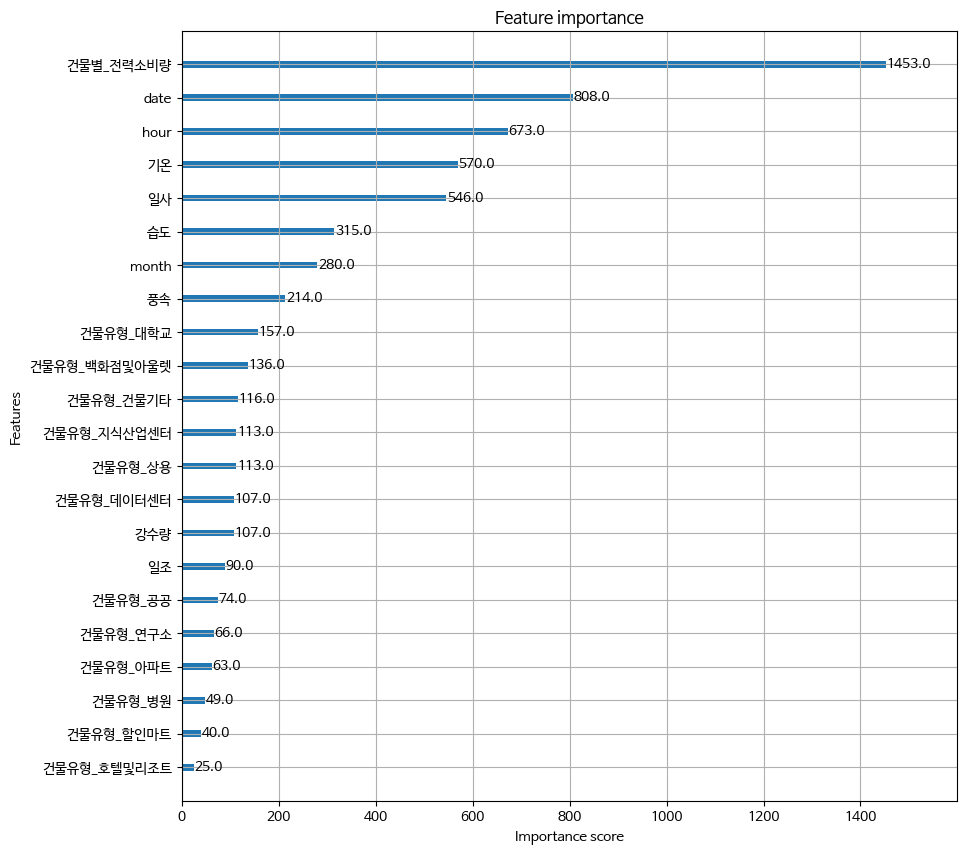

In [ ]:
# 그래프의 형태, 표기형식, 스케일, 수치는 사용하는 메소드에 따라 달라집니다.
# 출력형식은 달라도 되니 각 변수중요도의 우선순위 정도만 같은지 확인 해주세요
from xgboost import plot_importance
fig, axes = plt.subplots(figsize=(10, 10))
plot_importance(xgbr, ax=axes)

target encoding의 영향으로 건물별 전력소비량 변수의 중요도가 가장 높게 확인이 됩니다.  
이는 기존 타겟데이터로 부터 생성 된 변수이기에 감안 해야 할 내용입니다.  
**17. 그외 변수 중요도 및 현재까지 진행한 과정을 통해 파악할 수 있는 내용은 무엇이며 그에 따라 모델 퍼포먼스 향상을 위한 작업을 추가해야 한다면 어떤 방법을 사용할 수 있을지 자유롭게 기술 해봅시다.**  

In [ ]:
# 서술형 답변이 필요합니다. 아래에 주석 형태로 답변을 남겨주세요.


**18. 위에서 기술한 내용을 바탕으로 feature engineering을 자유롭게 진행하고 df.head()를 호출하여 작업 결과를 확인합니다.**  
**만약 sklearn.preprocessing 모델사용이 필요하다면 19번 항목에 해당 작업을 함께 적용합니다.**


In [ ]:
# CODE HERE


**19. 15번 문항에서 사용한 머신러닝 학습 코드를 사용하여 동일한 모델에 대해 학습을 수행하고 RMSE값을 확인합니다.**

In [ ]:
# CODE HERE


**20. feature engineering을 통해 모델 퍼포먼스의 개선이 있을 지 여부는 작업을 하기전 완벽한 도메인 지식이 없다면 알기가 어렵습니다. 17~19과정을 통해 퍼포먼스 개선 여부에 따라 분석가가 판단할 수 있는 내용은 무엇인지 자유롭게 기술 해봅시다.**

In [ ]:
# 서술형 답변이 필요합니다. 아래에 주석 형태로 답변을 남겨주세요.


# 수고하셨습니다